In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.28 s (started: 2026-07-17 01:26:42 +02:00)


In [2]:
!pip install -U topacedo

time: 1.15 s (started: 2026-07-17 01:26:43 +02:00)


In [3]:
# Loading preanalyzed dataset that was processed in the `basic_tutorial` vignette
scarf.fetch_dataset(
    dataset_name="tenx_5K_pbmc_rnaseq", as_zarr=True, save_path="scarf_datasets"
)

time: 17.7 s (started: 2026-07-17 01:26:45 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


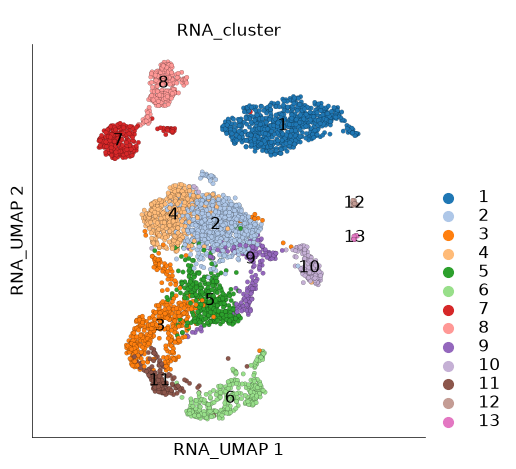

time: 1.19 s (started: 2026-07-17 01:27:01 +02:00)


In [4]:
ds = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr")

ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cluster")

In [5]:
ds.run_topacedo_sampler(cluster_key="RNA_cluster", max_sampling_rate=0.1)

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 202257.01it/s]

INFO: 384 cells (9.75%) sub-sampled. Subsample to Seed (165 cells) ratio: 2.327


time: 1.9 s (started: 2026-07-17 01:27:02 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


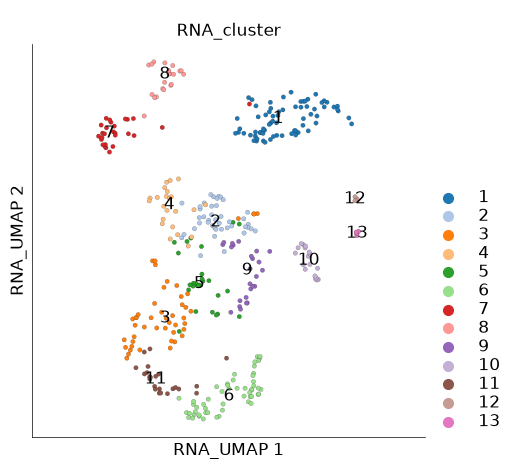

time: 682 ms (started: 2026-07-17 01:27:04 +02:00)


In [6]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="RNA_cluster", subselection_key="RNA_sketched"
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


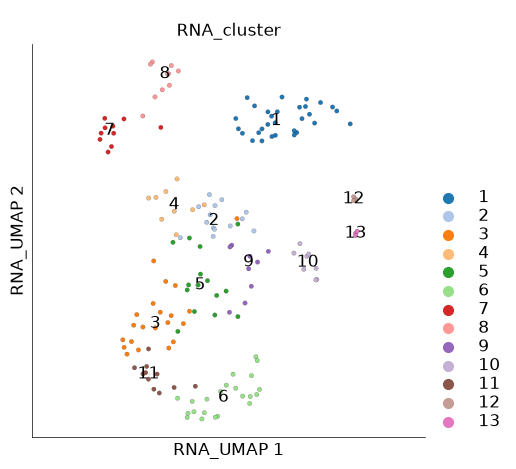

time: 628 ms (started: 2026-07-17 01:27:04 +02:00)


In [7]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="RNA_cluster", subselection_key="RNA_sketch_seeds"
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


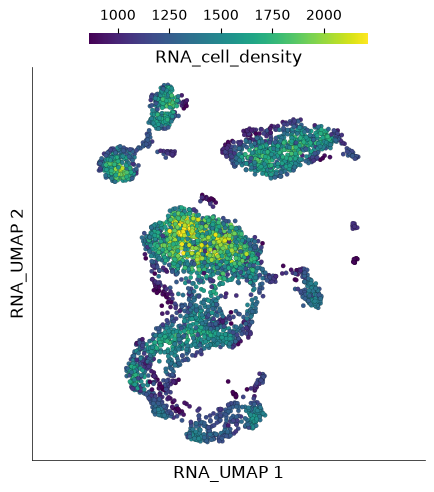

time: 578 ms (started: 2026-07-17 01:27:05 +02:00)


In [8]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cell_density")

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


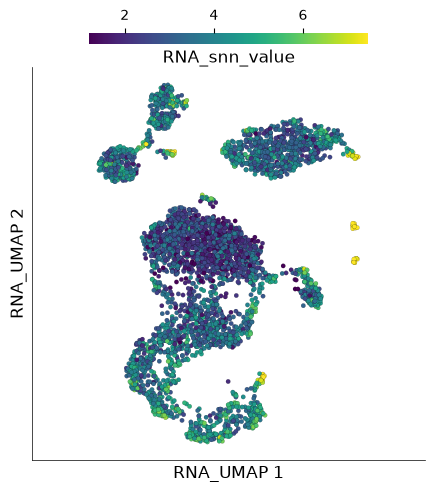

time: 577 ms (started: 2026-07-17 01:27:06 +02:00)


In [9]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_snn_value")

In [10]:
writer = scarf.SubsetZarr(
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr",
    assays=[ds.RNA],
    cell_key="RNA_sketched",
    reset_cell_filter=False,
)
writer.dump()

Writing countsT shape=(33538, 384) chunks=(33538, 384)



time: 1.54 s (started: 2026-07-17 01:27:06 +02:00)


In [11]:
ds2 = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr")

time: 1.31 s (started: 2026-07-17 01:27:08 +02:00)


In [12]:
ds2

DataStore has 384 (384) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'RNA_snn_value', 'RNA_cell_density', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts', 'RNA_cluster', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'RNA_sketched', 'RNA_UMAP1'
   RNA assay has 8773 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 121 ms (started: 2026-07-17 01:27:09 +02:00)


In [13]:
!pip install anndata

time: 934 ms (started: 2026-07-17 01:27:09 +02:00)


In [14]:
adata = ds2.to_anndata()

time: 1.14 s (started: 2026-07-17 01:27:10 +02:00)


In [15]:
adata

AnnData object with n_obs × n_vars = 384 × 33538
    obs: 'I', 'names', 'RNA_tSNE2', 'RNA_percentMito', 'RNA_cell_density', 'RNA_tSNE1', 'RNA_snn_value', 'RNA_sketch_seeds', 'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_cluster', 'RNA_UMAP2', 'RNA_sketched', 'RNA_UMAP1'
    var: 'I', 'names', 'nCells', 'dropOuts'

time: 4.06 ms (started: 2026-07-17 01:27:11 +02:00)
